In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input



In [23]:
MODEL_PATH = "Modelos/best_dog_emotion_model_final_2.keras"  # Cambia esto por tu archivo real

model = tf.keras.models.load_model(MODEL_PATH)

print("Modelo cargado correctamente")
model.summary()

Modelo cargado correctamente


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,642,010 (25.34 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 361,350 (1.38 MB)

In [24]:

class_names = ["angry", "happy", "relaxed", "sad"]

def convertir_a_jpg_si_es_necesario(ruta_imagen):
    extension = os.path.splitext(ruta_imagen)[1].lower()

    if extension in [".jpg", ".jpeg"]:
        return ruta_imagen

    nueva_ruta = os.path.splitext(ruta_imagen)[0] + ".jpg"

    img = Image.open(ruta_imagen)

    img = img.convert("RGB")

    img.save(nueva_ruta, "JPEG", quality=95)

    print(f"Imagen convertida a JPG: {nueva_ruta}")

    return nueva_ruta

In [25]:
def predecir_imagen(ruta_imagen):
    img_size = (224, 224)

    ruta_imagen = convertir_a_jpg_si_es_necesario(ruta_imagen)

    img = image.load_img(ruta_imagen, target_size=img_size)

    img_array = image.img_to_array(img)

    img_array_batch = np.expand_dims(img_array, axis=0)

    img_preprocesada = preprocess_input(img_array_batch)

    prediccion = model.predict(img_preprocesada)

    indice_predicho = np.argmax(prediccion[0])
    clase_predicha = class_names[indice_predicho]
    confianza = prediccion[0][indice_predicho]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase_predicha} | Confianza: {confianza*100:.2f}%")
    plt.show()

    print("Clase predicha:", clase_predicha)
    print(f"Confianza: {confianza*100:.2f}%")

    print("\nArray de probabilidades:")
    print(prediccion[0])

    print("\nProbabilidades por clase:")
    for clase, prob in zip(class_names, prediccion[0]):
        print(f"{clase}: {prob*100:.2f}%")

    return clase_predicha, confianza, prediccion[0]

Imagen convertida a JPG: Test_data/perro_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


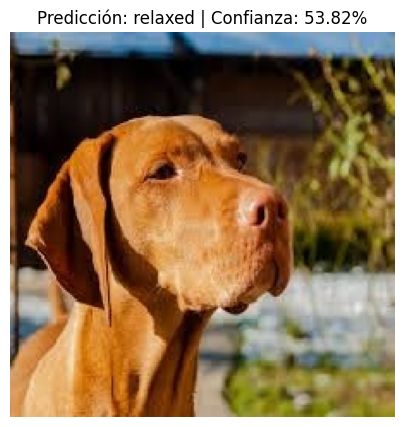

Clase predicha: relaxed
Confianza: 53.82%

Array de probabilidades:
[0.04891708 0.27601904 0.53818357 0.13688035]

Probabilidades por clase:
angry: 4.89%
happy: 27.60%
relaxed: 53.82%
sad: 13.69%


In [26]:
ruta = "Test_data/perro_3.jfif" 

clase, confianza, probabilidades = predecir_imagen(ruta)